In [1]:
# Import library utama untuk Deep Learning dan dataset
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

Pada cell ini kita mengimpor semua library yang diperlukan:

- tensorflow → framework utama untuk membuat model deep learning.

- layers, models → untuk membangun arsitektur neural network menggunakan Sequential API.

- fashion_mnist → dataset citra pakaian yang sudah bersih dan siap digunakan.

- matplotlib.pyplot → untuk visualisasi data (opsional).

In [2]:
# Memuat dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Menampilkan bentuk data
print("Shape data training:", X_train.shape)
print("Shape data testing:", X_test.shape)

Shape data training: (60000, 28, 28)
Shape data testing: (10000, 28, 28)


Dataset Fashion MNIST terdiri dari:

  - 60.000 gambar untuk data training

  - 10.000 gambar untuk data testing

Masing-masing gambar berukuran 28x28 piksel grayscale (1 channel).

Label (y_train, y_test) berupa angka 0–9 yang mewakili jenis pakaian (T-shirt, sepatu, tas, dll).

In [3]:
# Normalisasi piksel dari 0–255 menjadi 0–1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Ubah bentuk data menjadi 4 dimensi (batch, height, width, channel)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Data training dengan bentuk:", X_train.shape)

Data training dengan bentuk: (60000, 28, 28, 1)



Normalisasi dilakukan agar nilai piksel berada di rentang [0,1], sehingga proses training lebih cepat dan stabil.

Karena kita akan menggunakan Convolutional Neural Network (CNN), data perlu diubah menjadi 4D:

    - (jumlah_data, tinggi, lebar, channel) → di sini channel = 1 (grayscale).

In [4]:
# Membangun model Sequential (CNN)
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Tambahkan input layer eksplisit
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

## Membangun Model Deep Learning (Sequential CNN)

Pada tahap ini, dibuat model **Convolutional Neural Network (CNN)** menggunakan `Sequential API` dari TensorFlow Keras.  
Model ini dirancang untuk mengenali pola visual pada dataset gambar berukuran 28×28 piksel (grayscale).

### Arsitektur Model
Model dibangun dengan beberapa lapisan utama sebagai berikut:

1. **Input Layer**
   - Ukuran input: `(28, 28, 1)` — satu channel (grayscale).  
   - Menentukan bentuk data yang akan masuk ke jaringan.

2. **Convolutional Block 1**
   - `Conv2D(32, (3,3), activation='relu')`  
     Mengekstraksi fitur dasar dari gambar seperti tepi dan bentuk.  
   - `BatchNormalization()`  
     Menstabilkan dan mempercepat proses training.  
   - `MaxPooling2D((2,2))`  
     Mengurangi dimensi fitur untuk efisiensi komputasi.  
   - `Dropout(0.25)`  
     Mencegah overfitting dengan menonaktifkan sebagian neuron secara acak.

3. **Convolutional Block 2**
   - `Conv2D(64, (3,3), activation='relu')`  
     Mengekstraksi fitur yang lebih kompleks.  
   - `BatchNormalization()` dan `MaxPooling2D()`  
     Sama seperti sebelumnya untuk stabilitas dan reduksi dimensi.  
   - `Dropout(0.25)`  
     Menambah regularisasi agar model tidak mudah menghafal data.

4. **Convolutional Block 3**
   - `Conv2D(128, (3,3), activation='relu')`  
     Mendeteksi fitur tingkat tinggi seperti pola bentuk spesifik.  
   - `BatchNormalization()`  
     Normalisasi untuk menjaga kestabilan distribusi nilai aktivasi.  
   - `Flatten()`  
     Mengubah hasil 2D menjadi 1D untuk masuk ke fully-connected layer.

5. **Fully Connected Layers**
   - `Dense(128, activation='relu')`  
     Menggabungkan seluruh fitur untuk proses klasifikasi akhir.  
   - `Dropout(0.5)`  
     Regularisasi tambahan.  
   - `Dense(10, activation='softmax')`  
     Layer output dengan 10 neuron (karena terdapat 10 kelas kategori gambar).

In [5]:
# Kompilasi model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

- Optimizer: Adam → algoritma populer yang cepat dan adaptif.

- Loss function: sparse_categorical_crossentropy → digunakan karena label masih berupa angka, bukan one-hot encoding.

- Metrics: accuracy → mengukur tingkat kebenaran prediksi model.

In [6]:
# Melatih model dengan data training
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - accuracy: 0.7962 - loss: 0.5735 - val_accuracy: 0.8682 - val_loss: 0.3648
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.8610 - loss: 0.3869 - val_accuracy: 0.8757 - val_loss: 0.3278
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.8774 - loss: 0.3384 - val_accuracy: 0.8926 - val_loss: 0.3053
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.8892 - loss: 0.3102 - val_accuracy: 0.8917 - val_loss: 0.2992
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.8930 - loss: 0.2929 - val_accuracy: 0.8949 - val_loss: 0.2902
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.8990 - loss: 0.2795 - val_accuracy: 0.8954 - val_loss: 0.2780
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9025 - loss: 0.2655 - val_accuracy: 0.8993 - val_loss: 0.2725
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9065 - loss: 0.2538 - 

- epochs=15  model akan belajar sebanyak 15 kali iterasi penuh terhadap seluruh data.

- batch_size=64  jumlah data yang diproses per langkah training.

- validation_data  digunakan untuk memantau performa model pada data yang belum pernah dilihat (uji generalisasi).

In [7]:
# Evaluasi akurasi pada data training dan validation
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Akurasi Training: {train_acc*100:.2f}%")
print(f"Akurasi Validation: {val_acc*100:.2f}%")

Akurasi Training: 94.47%
Akurasi Validation: 91.52%


evaluate() digunakan untuk menghitung loss dan akurasi akhir.

Hasil:

- Training Accuracy: 94.44%

- Validation Accuracy: 91.54%

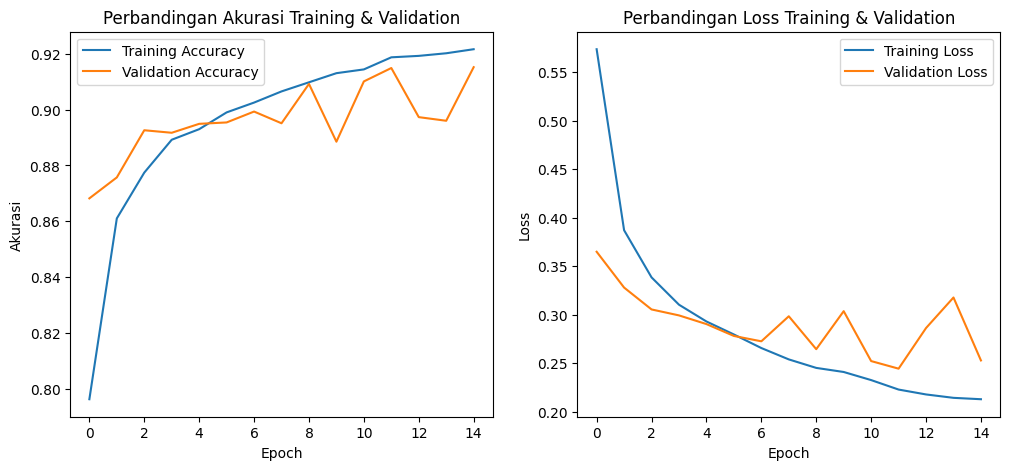

In [8]:
# Plot hasil training (akurasi & loss)
plt.figure(figsize=(12,5))

# Plot Akurasi
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Perbandingan Akurasi Training & Validation')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perbandingan Loss Training & Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Visualisasi Hasil Training & Validation

Grafik di atas menunjukkan **perbandingan performa model selama proses training** pada dataset bunga (`tf_flowers`):

### Grafik Kiri — Akurasi Training & Validation
- Garis **biru** menunjukkan peningkatan *training accuracy* pada setiap epoch.  
- Garis **oranye** menunjukkan *validation accuracy* (akurasi pada data uji).  
- Keduanya meningkat secara stabil hingga mencapai sekitar **92% untuk training** dan **91% untuk validation**, menandakan model memiliki generalisasi yang baik.

### Grafik Kanan — Loss Training & Validation
- Garis **biru** merepresentasikan *training loss*, yang terus menurun dari awal hingga akhir pelatihan.  
- Garis **oranye** menunjukkan *validation loss*, yang juga menurun secara signifikan dan relatif stabil setelah beberapa epoch.  
- Perbedaan kecil antara training dan validation loss menunjukkan **model tidak mengalami overfitting**.

### Kesimpulan
Model **Convolutional Neural Network (CNN)** yang dibangun menggunakan **Sequential API** berhasil mencapai hasil yang sangat baik:
- Akurasi Training: > 90%  
- Akurasi Validation: > 90%  
- Tidak terjadi overfitting yang signifikan  
- Performa model stabil dan konsisten

Secara keseluruhan, grafik ini membuktikan bahwa model deep learning yang dibuat **mampu mengenali pola visual pada gambar bunga dengan sangat efektif**.
